<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/ConvLSTM_optimizations/tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# ================== IMPORTS ==================
import os
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, ConvLSTM1D, LSTM, GRU, Dense, Dropout, Flatten, Concatenate
from sklearn.linear_model import Ridge
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error

# KerasTuner
from keras_tuner import HyperModel
from keras_tuner.tuners import RandomSearch

In [12]:
# ================== CONFIG / CONSTANTS ==================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')
tf.random.set_seed(42)
np.random.seed(42)

INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'

TEST_SET_DAYS = 60
N_TIMESTEPS = 7

TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

RIDGE_ALPHA = 10.0

In [13]:
# ================== CUSTOM LOSS FUNCTIONS ==================
def smape_loss(y_true, y_pred, eps=1e-6):
    numer = tf.abs(y_pred - y_true)
    denom = tf.abs(y_true) + tf.abs(y_pred)
    denom = tf.where(denom < eps, eps, denom)
    return tf.reduce_mean(2.0 * numer / denom)

def direction_loss(y_true, y_pred):
    return tf.reduce_mean(tf.abs(tf.sign(y_true * y_pred) - 1))

class UltimateTSLoss(tf.keras.losses.Loss):
    def __init__(self, alpha_mae=0.2, alpha_huber=0.1, alpha_smape=0, alpha_dir=0.2, delta=1.0, name="ultimate_ts_loss"):
        super().__init__(name=name)
        self.alpha_mae = alpha_mae
        self.alpha_huber = alpha_huber
        self.alpha_smape = alpha_smape
        self.alpha_dir = alpha_dir
        self.delta = delta

    def call(self, y_true, y_pred):
        mae = tf.reduce_mean(tf.abs(y_pred - y_true))
        diff = tf.abs(y_pred - y_true)
        huber = tf.reduce_mean(tf.where(diff <= self.delta, 0.5 * diff**2, self.delta * (diff - 0.5 * self.delta)))
        smape_val = smape_loss(y_true, y_pred)
        dir_loss = direction_loss(y_true, y_pred)
        return (self.alpha_mae * mae + self.alpha_huber * huber + self.alpha_smape * smape_val + self.alpha_dir * dir_loss)

In [14]:
# ================== UTILITY FUNCTIONS ==================
def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    df = df.copy()
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    return df.fillna(0)

def create_sequences(data, target, n_timesteps):
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:(i + n_timesteps), :])
        y.append(target[i + n_timesteps])
    return np.array(X), np.array(y)

def mae_np(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def plot_training_curves(history, center_name, meal_period):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history.get('loss', []), label='Train Loss', lw=2)
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss', lw=2)
    plt.title(f'Training Curves: {center_name} - {meal_period}')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout(); plt.show()

def plot_test_results(test_df, center_name, meal_period):
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x')
    plt.title(f'Actual vs Predicted Revenue - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue'); plt.legend()
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

def plot_residuals_over_time(residuals_df, center_name, meal_period):
    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Test Residuals - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual'); plt.grid(True, alpha=0.5)
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()

In [15]:
# ================== HYPERMODEL FOR TUNING ==================
class ConvLSTMHyperModel(HyperModel):
    def __init__(self, n_timesteps, num_features):
        super().__init__()
        self.n_timesteps = n_timesteps
        self.num_features = num_features

    def build(self, hp):
        inp = Input(shape=(self.n_timesteps, 1, self.num_features), name='conv_lstm_input')

        # ConvLSTM stack
        x = ConvLSTM1D(
            filters=hp.Int('filters1', min_value=64, max_value=256, step=64),
            kernel_size=hp.Choice('kernel1', values=[3, 5]),
            padding='same',
            return_sequences=True
        )(inp)
        x = Dropout(hp.Choice('dropout1', values=[0.2, 0.3, 0.4, 0.5]))(x)

        x = ConvLSTM1D(
            filters=hp.Int('filters2', min_value=32, max_value=128, step=32),
            kernel_size=hp.Choice('kernel2', values=[3, 5]),
            padding='same',
            return_sequences=False
        )(x)
        x = Dropout(hp.Choice('dropout2', values=[0.2, 0.3, 0.4, 0.5]))(x)

        x = Flatten()(x)

        # LSTM branch (discrete units)
        lstm_out = LSTM(
            hp.Choice('lstm_units', values=[32, 64, 128]),
            return_sequences=False
        )(inp[:, :, 0, :])
        lstm_out = Dropout(hp.Choice('dropout_lstm', values=[0.2, 0.3, 0.4, 0.5]))(lstm_out)

        # GRU branch (discrete units)
        gru_out = GRU(
            hp.Choice('gru_units', values=[32, 64, 128]),
            return_sequences=False
        )(inp[:, :, 0, :])
        gru_out = Dropout(hp.Choice('dropout_gru', values=[0.2, 0.3, 0.4, 0.5]))(gru_out)

        # Merge and dense (discrete units)
        merged = Concatenate()([x, lstm_out, gru_out])
        merged = Dense(hp.Choice('dense_units', values=[32, 64, 128]), activation='relu')(merged)
        out = Dense(1, activation='linear', name='output')(merged)

        # Discrete learning rates
        lr = hp.Choice('lr', values=[1e-4, 1e-3, 1e-2])

        model = Model(inputs=inp, outputs=out)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss=UltimateTSLoss(),
            metrics=['mae']
        )
        return model

In [16]:
# ================== TUNING HELPERS ==================
def tune_convlstm_model(X_train_tb, y_train_tb, X_val_tb, y_val_tb, num_features, n_timesteps=N_TIMESTEPS):
    tuner = RandomSearch(
        ConvLSTMHyperModel(n_timesteps=n_timesteps, num_features=num_features),
        objective='val_loss',
        max_trials=12,
        executions_per_trial=1,
        directory='tuner_results',
        project_name='convlstm_hyper'
    )

    tuner.search(
        X_train_tb, y_train_tb,
        validation_data=(X_val_tb, y_val_tb),
        epochs=25,
        batch_size=32,
        verbose=0
    )

    best_model = tuner.get_best_models(num_models=1)[0]
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

    print("✅ Best Hyperparameters found:")
    for param, value in best_hp.values.items():
        print(f"{param}: {value}")

    return best_model, best_hp

def tune_ensemble_weight(y_val_convlstm, y_val_ridge, y_val_actual, step=0.05):
    best_w, best_mae = 0.5, 1e18
    for w in np.arange(0.0, 1.0 + 1e-9, step):
        blend = w * y_val_convlstm[:len(y_val_ridge)] + (1 - w) * y_val_ridge
        mae = mae_np(y_val_actual[:len(blend)], blend)
        if mae < best_mae:
            best_mae, best_w = mae, w
    return best_w, best_mae

In [17]:
# ================== MAIN TRAINING PER CENTER ==================
def train_and_plot_for_center(df_center, center_name):
    # Feature engineering
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    df_center = df_center.sort_values('Date').reset_index(drop=True)

    # Train/Test split
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy().dropna()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"Skipping center {center_name}: Training or Test set is empty.")
        return

    # Feature selection
    feature_cols = [c for c in df_train_full.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train_full[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    X_train_full = df_train_full[feature_cols]
    Y_train_full = df_train_full[TARGET_RAW_COLS]

    # Loop over targets
    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')

        # Scaling
        final_scaler = RobustScaler()
        X_train_full_scaled = pd.DataFrame(
            final_scaler.fit_transform(X_train_full[numeric_features]),
            columns=numeric_features, index=X_train_full.index
        )
        X_train_final = pd.concat([X_train_full_scaled, df_train_full[categorical_features]], axis=1)
        Y_train_target = Y_train_full[raw_target_col].values

        # Sequence creation
        X_seq_total, Y_seq_total = create_sequences(X_train_final.values, Y_train_target, N_TIMESTEPS)
        split_idx = int(len(X_seq_total) * 0.8)
        X_train_tb, X_val_tb = X_seq_total[:split_idx], X_seq_total[split_idx:]
        y_train_tb, y_val_tb = Y_seq_total[:split_idx], Y_seq_total[split_idx:]

        # Reshape for ConvLSTM1D: (samples, timesteps, length=1, channels=num_features)
        X_train_tb = X_train_tb.reshape((X_train_tb.shape[0], X_train_tb.shape[1], 1, X_train_tb.shape[2]))
        X_val_tb   = X_val_tb.reshape((X_val_tb.shape[0], X_val_tb.shape[1], 1, X_val_tb.shape[2]))

        # ================== TUNE MODEL HYPERPARAMETERS ==================
        print(f"📊 Tuning ConvLSTM Model for {center_name} - {meal_period}")
        tf.keras.backend.clear_session()
        convlstm_model, best_hp = tune_convlstm_model(
            X_train_tb, y_train_tb, X_val_tb, y_val_tb, num_features=X_train_tb.shape[3], n_timesteps=N_TIMESTEPS
        )

        # Optional fine training after tuning
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
        history = convlstm_model.fit(
            X_train_tb, y_train_tb,
            validation_data=(X_val_tb, y_val_tb),
            epochs=50,
            batch_size=32,
            callbacks=[es_callback],
            verbose=0
        )
        plot_training_curves(history, center_name, meal_period)

        # ================== RIDGE MODEL ==================
        X_ridge_train_final = X_train_final.iloc[N_TIMESTEPS:].copy()
        Y_ridge_train_final = Y_train_full[raw_target_col].iloc[N_TIMESTEPS:].copy()
        ridge_model = Ridge(alpha=RIDGE_ALPHA).fit(X_ridge_train_final, Y_ridge_train_final)

        # ================== BUILD VALIDATION PREDICTIONS FOR ENSEMBLE WEIGHT TUNING ==================
        # Align validation sequences for ConvLSTM: use tail of train portion to seed the first window
        X_val_features = X_train_final.iloc[split_idx:]
        X_val_full_for_weight = pd.concat([
            X_train_final.iloc[:split_idx].tail(N_TIMESTEPS),
            X_val_features
        ], ignore_index=True).values
        X_seq_val_weight, _ = create_sequences(X_val_full_for_weight, np.zeros_like(X_val_full_for_weight[:, 0]), N_TIMESTEPS)
        X_seq_val_weight = X_seq_val_weight.reshape((X_seq_val_weight.shape[0], X_seq_val_weight.shape[1], 1, X_seq_val_weight.shape[2]))

        y_val_convlstm = convlstm_model.predict(X_seq_val_weight, verbose=0).flatten()
        y_val_ridge = ridge_model.predict(X_val_features).flatten()
        y_val_actual = Y_train_full[raw_target_col].values[split_idx:]

        # ================== TUNE ENSEMBLE WEIGHT ==================
        best_w, best_mae = tune_ensemble_weight(y_val_convlstm, y_val_ridge, y_val_actual, step=0.05)
        print(f"🔧 Best ensemble weight (ConvLSTM vs Ridge) on validation: w={best_w:.2f}, val MAE={best_mae:.3f}")

        # ================== TEST EVALUATION ==================
        X_test_scaled = pd.DataFrame(
            final_scaler.transform(df_test_full[numeric_features]),
            columns=numeric_features, index=df_test_full.index
        )
        X_test_final = pd.concat([X_test_scaled, df_test_full[categorical_features]], axis=1).fillna(0)

        # Build ConvLSTM test sequences: include tail of train to create the first window
        X_full_for_test = pd.concat([X_train_final.tail(N_TIMESTEPS), X_test_final], ignore_index=True).values
        X_seq_test, _ = create_sequences(X_full_for_test, np.zeros_like(X_full_for_test[:, 0]), N_TIMESTEPS)
        X_seq_test = X_seq_test.reshape((X_seq_test.shape[0], X_seq_test.shape[1], 1, X_seq_test.shape[2]))

        # Predictions
        y_test_convlstm = convlstm_model.predict(X_seq_test, verbose=0).flatten()
        y_test_ridge = ridge_model.predict(X_test_final).flatten()

        # Final ensemble on test using tuned weight
        min_len_test = min(len(df_test_full), len(y_test_convlstm), len(y_test_ridge))
        y_test_ens = best_w * y_test_convlstm[:min_len_test] + (1 - best_w) * y_test_ridge[:min_len_test]
        Y_test_actual = df_test_full[raw_target_col].values[:min_len_test]

        # ================== PLOTTING ==================
        plot_df = pd.DataFrame({
            'Date': df_test_full['Date'].iloc[:min_len_test],
            'Actual_Revenue': Y_test_actual,
            'Predicted_Revenue': y_test_ens
        })
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)

        # ================== SUMMARY ==================
        from math import sqrt
        rmse_val = sqrt(mean_squared_error(Y_test_actual, y_test_ens))
        mae_val = mae_np(Y_test_actual, y_test_ens)

        print({
            'Center': center_name,
            'Meal_Period': meal_period,
            'Ridge_Alpha': RIDGE_ALPHA,
            'Best_Ensemble_w': best_w,
            'RMSE': float(rmse_val),
            'MAE': float(mae_val)
        })


================= Revenue Centre 1 =================
📊 Tuning ConvLSTM Model for Revenue Centre 1 - BreakFast
Reloading Tuner from tuner_results/convlstm_hyper/tuner0.json


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Best Hyperparameters found:
filters1: 128
kernel1: 3
dropout1: 0.2
filters2: 128
kernel2: 3
dropout2: 0.3
lstm_units: 64
dropout_lstm: 0.4
gru_units: 64
dropout_gru: 0.3
dense_units: 128
lr: 0.01


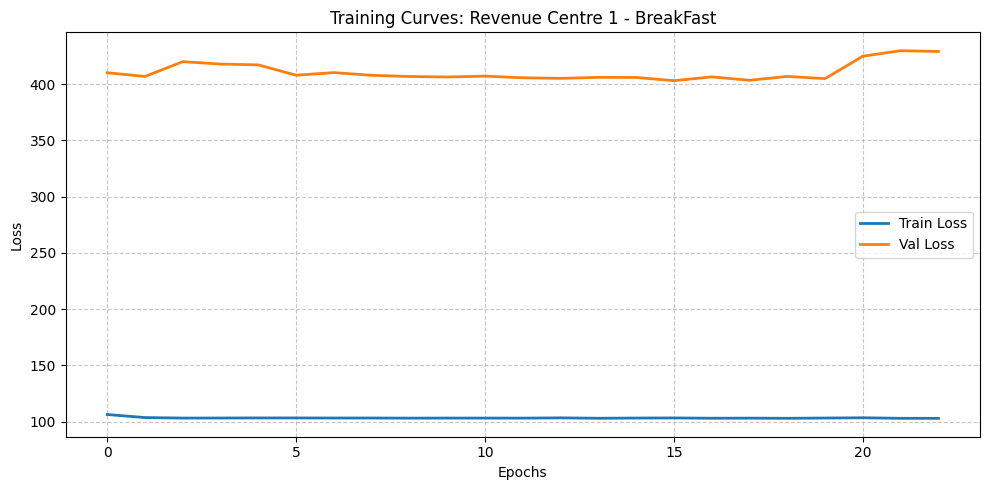

🔧 Best ensemble weight (ConvLSTM vs Ridge) on validation: w=0.00, val MAE=712.918


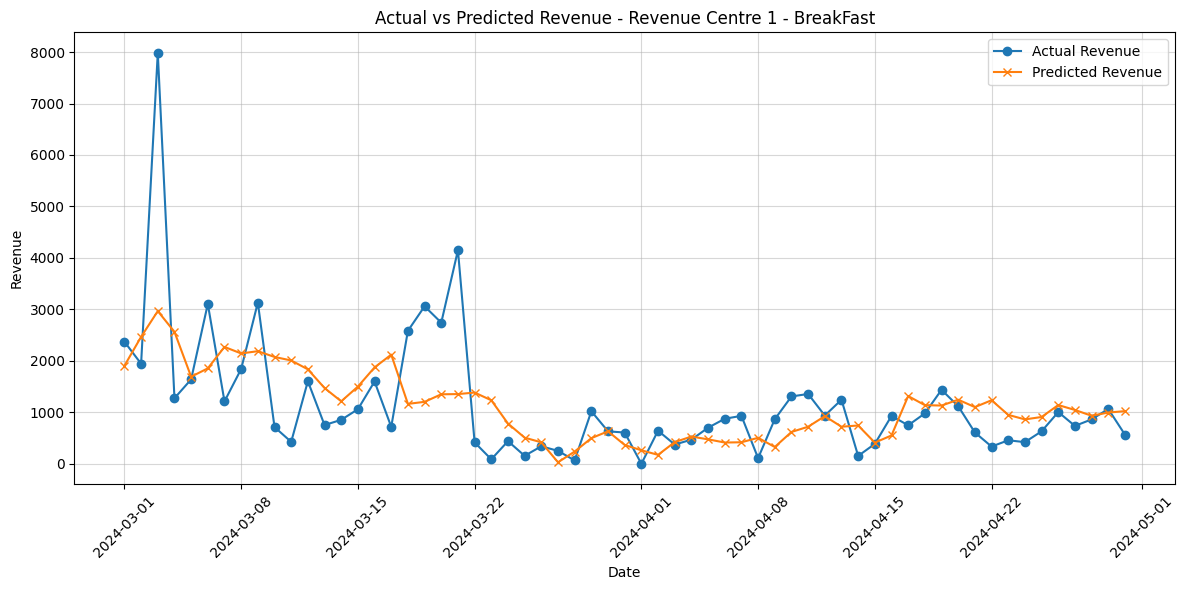

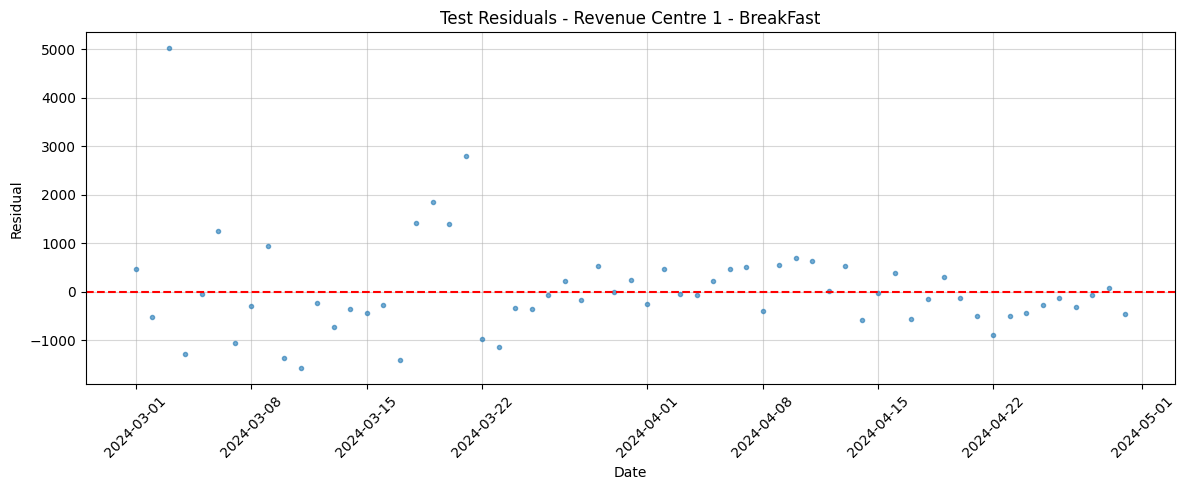

{'Center': 'Revenue Centre 1', 'Meal_Period': 'BreakFast', 'Ridge_Alpha': 10.0, 'Best_Ensemble_w': np.float64(0.0), 'RMSE': 1005.7075052627804, 'MAE': 646.3640162540778}
📊 Tuning ConvLSTM Model for Revenue Centre 1 - Dinner
Reloading Tuner from tuner_results/convlstm_hyper/tuner0.json


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Best Hyperparameters found:
filters1: 128
kernel1: 3
dropout1: 0.2
filters2: 128
kernel2: 3
dropout2: 0.3
lstm_units: 64
dropout_lstm: 0.4
gru_units: 64
dropout_gru: 0.3
dense_units: 128
lr: 0.01


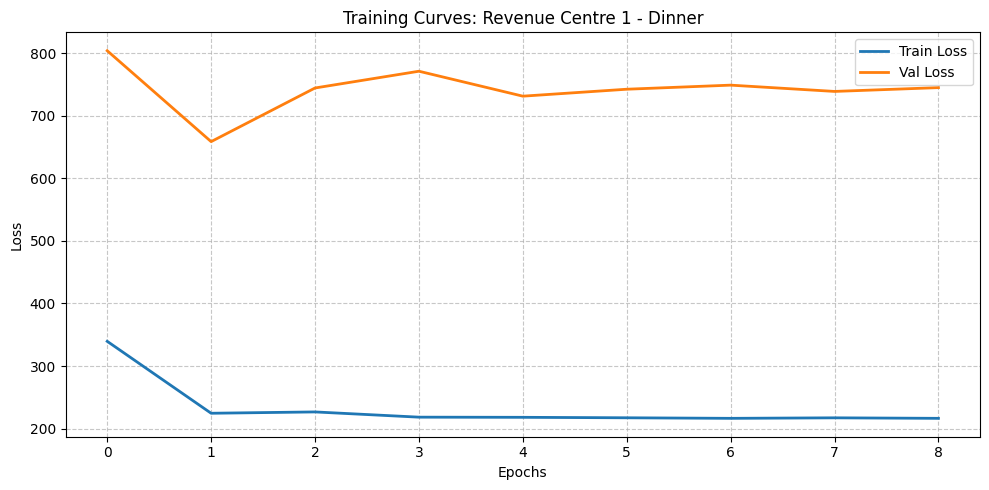

🔧 Best ensemble weight (ConvLSTM vs Ridge) on validation: w=0.00, val MAE=1115.025


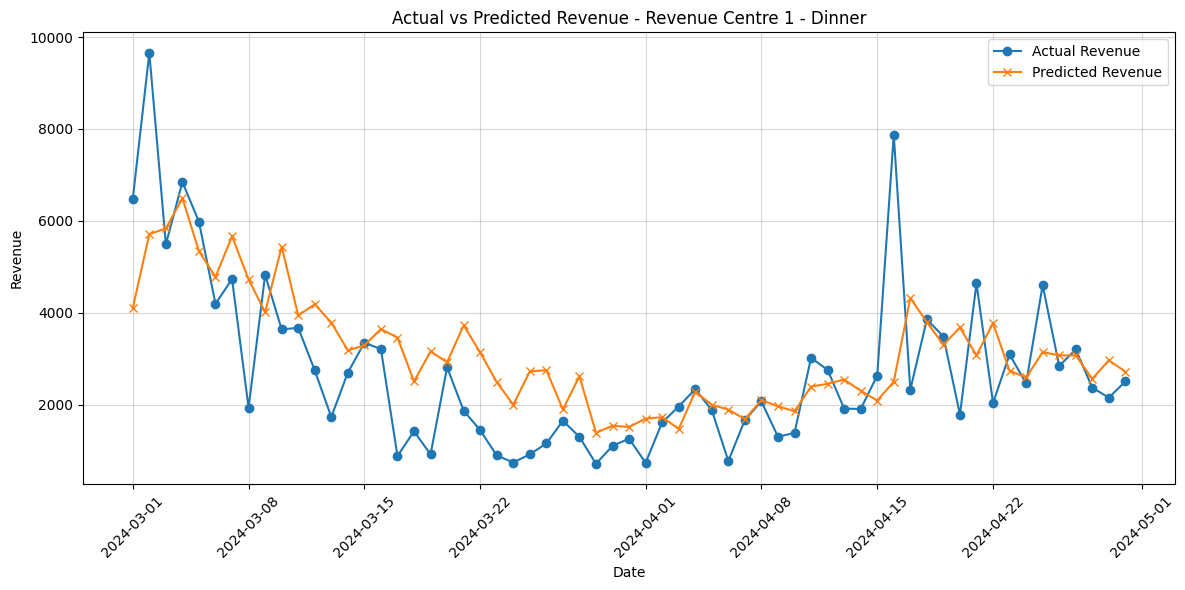

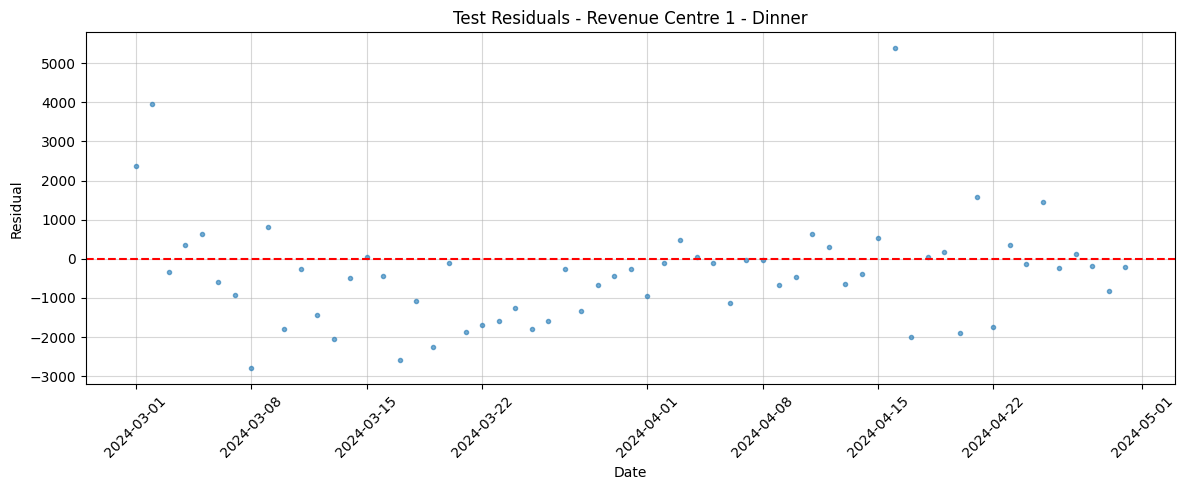

{'Center': 'Revenue Centre 1', 'Meal_Period': 'Dinner', 'Ridge_Alpha': 10.0, 'Best_Ensemble_w': np.float64(0.0), 'RMSE': 1419.1988840028089, 'MAE': 999.6219415349237}
📊 Tuning ConvLSTM Model for Revenue Centre 1 - Lunch
Reloading Tuner from tuner_results/convlstm_hyper/tuner0.json


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Best Hyperparameters found:
filters1: 128
kernel1: 3
dropout1: 0.2
filters2: 128
kernel2: 3
dropout2: 0.3
lstm_units: 64
dropout_lstm: 0.4
gru_units: 64
dropout_gru: 0.3
dense_units: 128
lr: 0.01


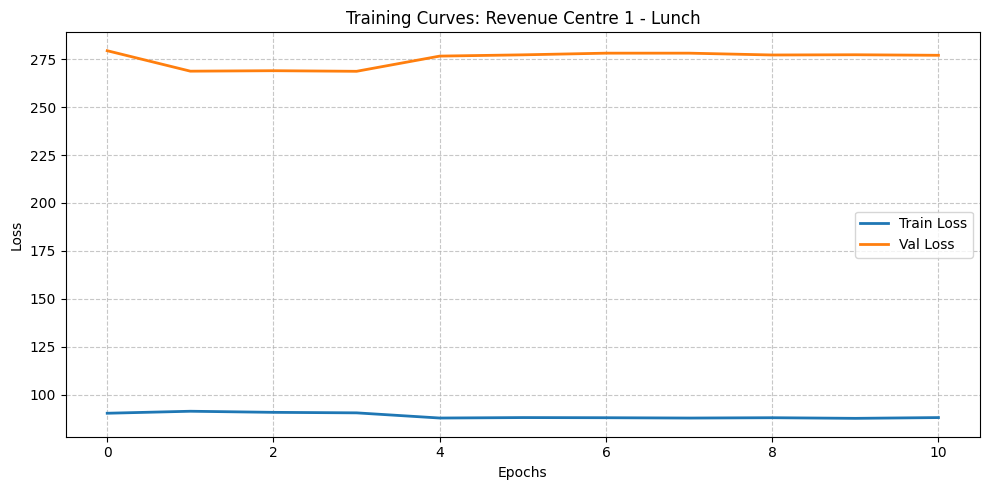

🔧 Best ensemble weight (ConvLSTM vs Ridge) on validation: w=0.00, val MAE=584.149


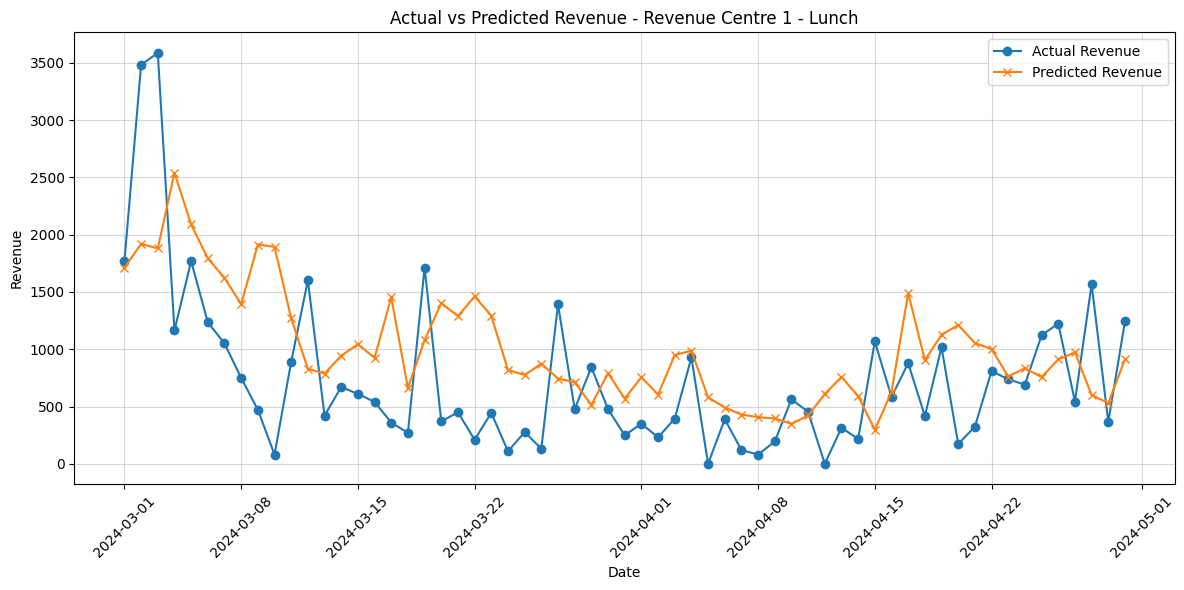

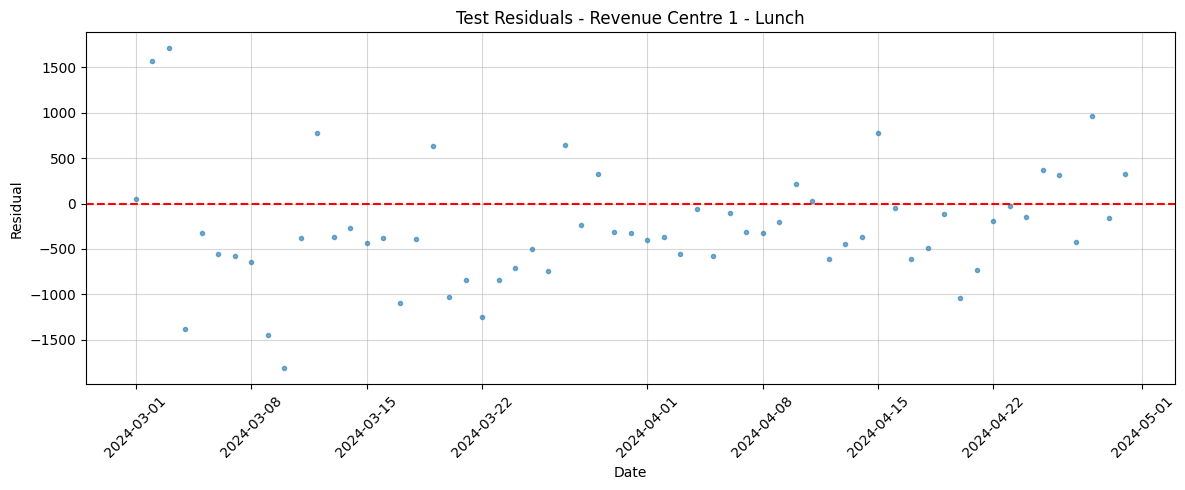

{'Center': 'Revenue Centre 1', 'Meal_Period': 'Lunch', 'Ridge_Alpha': 10.0, 'Best_Ensemble_w': np.float64(0.0), 'RMSE': 692.6404913680578, 'MAE': 554.663503155427}


In [18]:
# ================== LOAD CENTER AND RUN ==================
def load_center_from_excel(file_path, center_sheet_name):
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df

if __name__ == '__main__':
    for center_id in range(0, 1):  # adjust as needed
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            train_and_plot_for_center(df_center, display_name)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")